In [1]:
import time
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
from matplotlib.colors import Normalize
from PIL import Image


from pc import PS
from modules import ADC,DAC,CHIP
from cimCommand import CMD,CmdData,Packet
from cimCommand.singleCmdInfo import *

from util import plot_cond,show_crossbar,read_crossbar_sub_base

In [2]:
chip=CHIP(PS(host="192.168.1.10", port = 7, debug=0),init=True)
chip.set_device_cfg(deviceType=0)

Connected to 192.168.1.10:7
local ip: 192.168.1.15 local port: 60710


In [5]:
def show_add_row(chip,row_num1,row_num2):
    need_read = np.zeros((256,256))

    need_read[row_num1,:]=1
    res1 = read_crossbar_sub_base(chip,need_read)[row_num1,:]

    need_read[row_num2,:]=1
    # need_read[255,:]=1
    voltage_base = chip.compute(crossbar=need_read, read_voltage=0,tg=5,gain=1,from_row=True,out_type=0)
    voltage = chip.compute(crossbar=need_read, read_voltage=0.1,tg=5,gain=1,from_row=True,out_type=0)
    cond_sub_base = chip.voltage_to_cond(voltage-voltage_base)
    sum12 = cond_sub_base[0,:]
    # print(cond_sub_base.shape)

    need_read[row_num1,:]=0
    res2 = read_crossbar_sub_base(chip,need_read)[row_num2,:]

    # plt.plot(res1,label = f"row = {row_num1}")
    # plt.plot(res2,label = f"row = {row_num2}")
    plt.title(f"row1 = {row_num1},row2 = {row_num2}")
    plt.plot(sum12,label = f"row = sum_by_read")
    plt.plot(res1+res2,label = f"row = sum_by_add")
    plt.legend()
    plt.show()

需要读256个点
需要读256个点
需要计算256次
需要计算256次
需要读256个点
需要读256个点


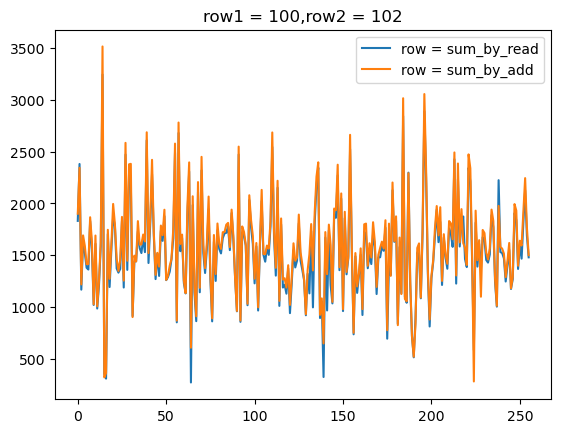

In [10]:
show_add_row(chip,100,102)